# 12 — v3 예측구간: static CQR의 실패 → 온라인 conformal (plan §3.1)

> 기말 플랜 **§3.1 (T1)** · XGBoost v3(13변수) 분위수 기반

## 문제 (3겹)
- (a) q05/q50/q95 독립 학습 → 분위수 교차 → **비교차 정렬**로 해결
- (b) **고정 CQR의 조건부 커버리지 실패**: 단일 시점 cal로 고정 Q̂ → 레짐이 바뀌면 깨짐
- (c) **방향과 분리**: 제대로 보정된 90% 구간은 0을 거의 항상 포함 → 구간 자체엔 방향 정보 없음

## 핵심 발견 (정직)
1. **고정(static) CQR은 실패한다** — fold3 과보정(99%/25bp), fold2 미달(67%). cal(과거 한 시점)≠test(다른 레짐)이면 exchangeability 붕괴.
2. **온라인 롤링 conformal이 해결** — 최근 W=125일 실현 잔차로 Q̂를 매일 갱신(Gibbs&Candès 2021; 과거값만→누수 없음) → 마진 0.905·세 fold 0.88~0.92·폭 14.8bp.
3. **그러나 방향은 구간이 아니라 q50 부호에서** — 제대로 보정하면 0배제율≈0. 일별 금리변화는 노이즈라 90% 구간은 0을 포함하는 게 정상.

### ⚠️ 정직성
- 온라인 Q̂는 **과거 실현 잔차만** 사용(미래 누수 없음).
- 분포무가정에서 *정확한* 조건부 커버리지는 불가(Vovk; Lei&Wasserman) → **"근사 조건부 커버리지 개선"**으로 주장.
- 0 배제 인위 강제 금지 — 자연 발생만 신호로 인정.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['font.family']='Malgun Gothic'; plt.rcParams['axes.unicode_minus']=False; plt.rcParams['figure.dpi']=100
PROJECT_ROOT=Path.cwd().parent
REP=PROJECT_ROOT/'reports'/'no_leak_v2'; FIG=PROJECT_ROOT/'reports'/'figures'/'v3'; FIG.mkdir(parents=True,exist_ok=True)
ALPHA=0.10
C={'raw':'#9aa3ad','sym':'#3b7dd8','asym':'#e0a458','local':'#c07cc0','online':'#2a9d63'}
NM={'raw':'raw(보정X)','sym':'고정 대칭 CQR','asym':'고정 비대칭','local':'고정 국소적응','online':'온라인 롤링'}
iv=pd.read_csv(REP/'predictions_xgb_v3_intervals.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
y=iv['y_true'].values
def cov(lo,hi): return float(((y>=lo)&(y<=hi)).mean())
def width(lo,hi): return float(np.mean(hi-lo))
def iscore(lo,hi): return float(np.mean((hi-lo)+(2/ALPHA)*(lo-y)*(y<lo)+(2/ALPHA)*(y-hi)*(y>hi)))
def excl0(lo,hi): return float(((lo>0)|(hi<0)).mean())
print(iv.shape, '|', iv['date'].min().date(),'~',iv['date'].max().date())

(1410, 16) | 2020-01-02 ~ 2025-12-30


---
## 1. 진단 — raw 구간폭은 "평탄"(등분산)

일별 금리변화는 평균0 노이즈 → raw 분위수가 거의 등분산 → 폭이 변동성과 무관하게 평탄. 고변동기(2020·2022)에도 평탄하면 가변폭(적응형) 동기 입증.

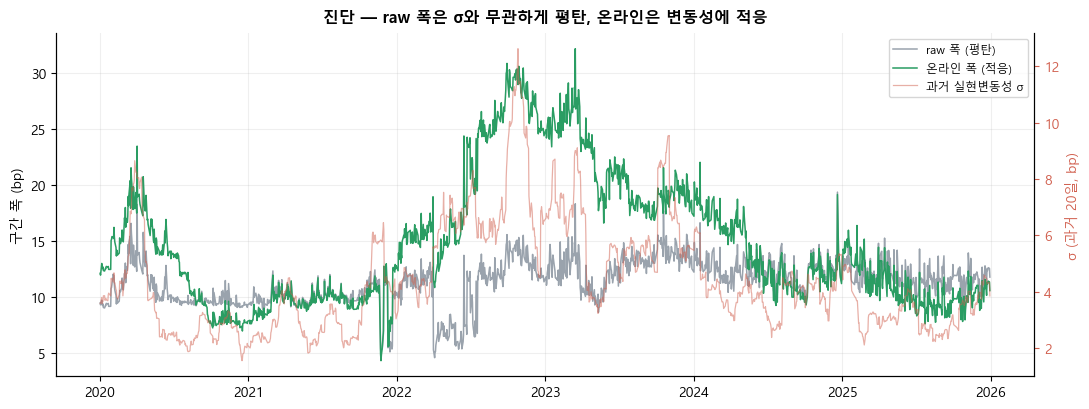

raw 폭 변동계수=0.172 | 온라인=0.394


In [2]:
fig,ax=plt.subplots(figsize=(11,4.2))
w_raw=iv['raw_hi']-iv['raw_lo']; w_on=iv['online_hi']-iv['online_lo']
ax.plot(iv['date'], w_raw, color=C['raw'], lw=1.1, label='raw 폭 (평탄)')
ax.plot(iv['date'], w_on, color=C['online'], lw=1.1, label='온라인 폭 (적응)')
ax.set_ylabel('구간 폭 (bp)')
ax2=ax.twinx(); ax2.plot(iv['date'], iv['sigma'], color='#d1604f', lw=0.9, alpha=0.5, label='과거 실현변동성 σ')
ax2.set_ylabel('σ (과거 20일, bp)', color='#d1604f'); ax2.tick_params(axis='y', colors='#d1604f')
l1,la1=ax.get_legend_handles_labels(); l2,la2=ax2.get_legend_handles_labels(); ax.legend(l1+l2,la1+la2,fontsize=8.5,loc='upper right')
ax.set_title('진단 — raw 폭은 σ와 무관하게 평탄, 온라인은 변동성에 적응', fontweight='bold', fontsize=11.5, pad=8)
ax.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False); ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig(FIG/'12_width_diagnostic.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'raw 폭 변동계수={w_raw.std()/w_raw.mean():.3f} | 온라인={w_on.std()/w_on.mean():.3f}')

---
## 2. 문제 — 고정(static) CQR은 조건부 커버리지가 실패한다

고정 CQR(대칭·비대칭·국소적응)은 cal 한 시점의 Q̂를 test 전체에 고정 적용한다. **fold별로 보면 무너진다**: fold3은 과보정(폭만 키움), fold2(인상기)는 cal(2020 코로나)와 달라 미달. pooled 숫자는 이 양극단을 가려버린다.

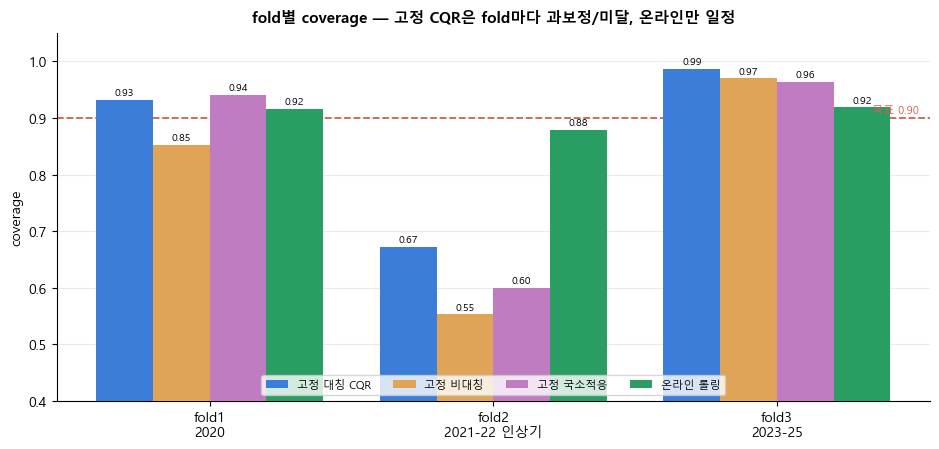

   method  pooled_cov  width_bp  IntervalScore  excl0
 raw(보정X)       0.830    11.343         22.947  0.010
고정 대칭 CQR       0.872    17.813         27.373  0.024
   고정 비대칭       0.811    13.949         27.109  0.034
  고정 국소적응       0.838    14.020         26.196  0.042
   온라인 롤링       0.905    14.845         19.994  0.003


In [3]:
folds=['fold1','fold2','fold3']; ms=['sym','asym','local','online']
fig,ax=plt.subplots(figsize=(9.5,4.6))
x=np.arange(len(folds)); w=0.2
for j,m in enumerate(ms):
    covs=[]
    for f in folds:
        g=iv[iv['fold']==f]; yy=g['y_true'].values
        covs.append(float(((yy>=g[f'{m}_lo'])&(yy<=g[f'{m}_hi'])).mean()))
    b=ax.bar(x+(j-1.5)*w, covs, w, color=C[m], label=NM[m], zorder=3)
    for bb,v in zip(b,covs): ax.text(bb.get_x()+bb.get_width()/2, v+0.005, f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)
ax.axhline(0.90, color='#d1604f', ls='--', lw=1.3); ax.text(2.5,0.91,'목표 0.90',color='#d1604f',fontsize=8,ha='right')
ax.set_xticks(x); ax.set_xticklabels(['fold1\n2020','fold2\n2021-22 인상기','fold3\n2023-25']); ax.set_ylim(0.4,1.05)
ax.set_ylabel('coverage'); ax.set_title('fold별 coverage — 고정 CQR은 fold마다 과보정/미달, 온라인만 일정', fontweight='bold', fontsize=11, pad=8)
ax.legend(fontsize=8, ncol=4, loc='lower center'); ax.spines[['top','right']].set_visible(False); ax.grid(axis='y',alpha=0.25,zorder=0)
plt.tight_layout(); plt.savefig(FIG/'12_perfold_coverage.png', dpi=150, bbox_inches='tight'); plt.show()
# 표
rows=[]
for m in ['raw','sym','asym','local','online']:
    lo,hi=iv[f'{m}_lo'].values, iv[f'{m}_hi'].values
    rows.append({'method':NM[m],'pooled_cov':cov(lo,hi),'width_bp':width(lo,hi),'IntervalScore':iscore(lo,hi),'excl0':excl0(lo,hi)})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v:f'{v:.3f}'))

---
## 3. 해결 — 온라인 롤링 conformal

최근 **W=125일 실현 잔차**로 Q̂를 매일 갱신 → 레짐 변화를 자동 추종(과거값만 사용, 누수 없음). 결과: 고정 대칭 CQR 대비 **마진 커버리지 0.872→0.905, 폭 17.8→14.8bp, Interval Score 27.4→20.0**(낮을수록 좋음), 레짐 균형까지 개선.

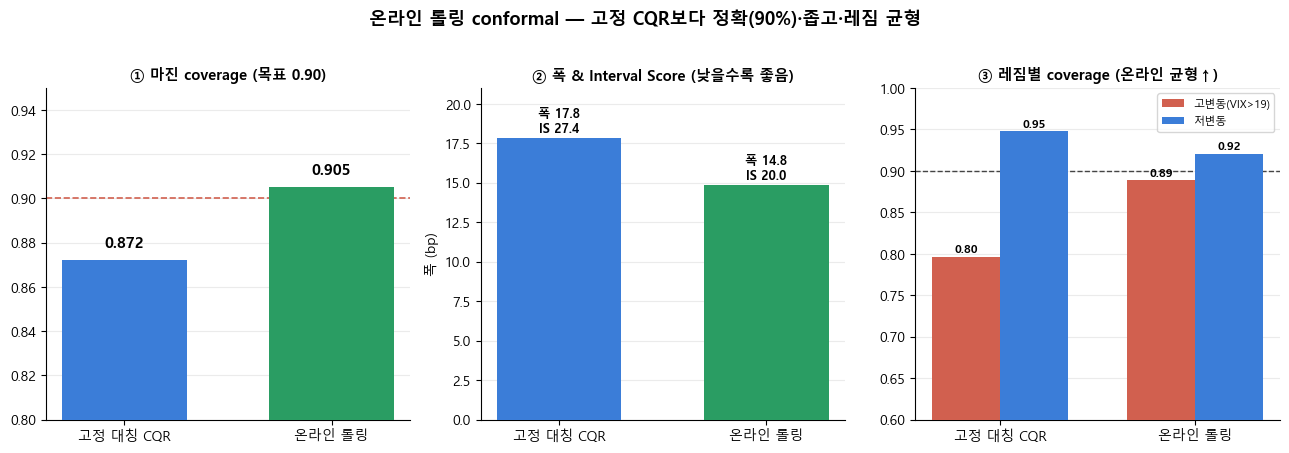

In [4]:
fig,axes=plt.subplots(1,3,figsize=(13,4.4))
two=['sym','online']; cols=[C['sym'],C['online']]; labs=[NM['sym'],NM['online']]
# (1) pooled coverage
ax=axes[0]; vals=[cov(iv[f'{m}_lo'],iv[f'{m}_hi']) for m in two]
b=ax.bar(labs,vals,color=cols,width=0.6,zorder=3)
for bb,v in zip(b,vals): ax.text(bb.get_x()+bb.get_width()/2,v+0.004,f'{v:.3f}',ha='center',va='bottom',fontsize=11,fontweight='bold')
ax.axhline(0.90,color='#d1604f',ls='--',lw=1.2); ax.set_ylim(0.8,0.95); ax.set_title('① 마진 coverage (목표 0.90)',fontweight='bold',fontsize=10.5)
# (2) width + interval score
ax=axes[1]; wid=[width(iv[f'{m}_lo'],iv[f'{m}_hi']) for m in two]; iss=[iscore(iv[f'{m}_lo'],iv[f'{m}_hi']) for m in two]
b=ax.bar(labs,wid,color=cols,width=0.6,zorder=3)
for bb,v,s in zip(b,wid,iss): ax.text(bb.get_x()+bb.get_width()/2,v+0.2,f'폭 {v:.1f}\nIS {s:.1f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
ax.set_ylabel('폭 (bp)'); ax.set_title('② 폭 & Interval Score (낮을수록 좋음)',fontweight='bold',fontsize=10.5); ax.set_ylim(0,21)
# (3) regime coverage
ax=axes[2]; med=np.nanmedian(iv['vix']); hm=iv['vix']>med; xx=np.arange(2); wb=0.35
ch=[float((((y>=iv[f'{m}_lo'])&(y<=iv[f'{m}_hi']))[hm]).mean()) for m in two]
cl=[float((((y>=iv[f'{m}_lo'])&(y<=iv[f'{m}_hi']))[~hm]).mean()) for m in two]
ax.bar(xx-wb/2,ch,wb,color='#d1604f',label=f'고변동(VIX>{med:.0f})',zorder=3)
ax.bar(xx+wb/2,cl,wb,color='#3b7dd8',label=f'저변동',zorder=3)
for i in range(2):
    ax.text(i-wb/2,ch[i]+0.005,f'{ch[i]:.2f}',ha='center',fontsize=8.5,fontweight='bold'); ax.text(i+wb/2,cl[i]+0.005,f'{cl[i]:.2f}',ha='center',fontsize=8.5,fontweight='bold')
ax.axhline(0.90,color='#444',ls='--',lw=1); ax.set_xticks(xx); ax.set_xticklabels(labs); ax.set_ylim(0.6,1.0)
ax.set_title('③ 레짐별 coverage (온라인 균형↑)',fontweight='bold',fontsize=10.5); ax.legend(fontsize=8)
for a in axes: a.spines[['top','right']].set_visible(False); a.grid(axis='y',alpha=0.25,zorder=0)
fig.suptitle('온라인 롤링 conformal — 고정 CQR보다 정확(90%)·좁고·레짐 균형', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(FIG/'12_online_solution.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 4. 방향 결합의 현실 — 제대로 보정하면 구간은 방향을 못 준다 (정직)

고정 CQR에서 0배제율이 높아 보였던 건 **fold2가 미달(구간이 너무 좁음)** 한 부산물이었다. 온라인으로 **제대로 90% 보정하면 0배제율≈0** — 일별 금리변화는 노이즈라 90% 구간은 거의 항상 0을 포함한다.

> 결론: **방향 신호는 예측구간이 아니라 q50의 부호**에서 온다(노트북 11: 방향정확도 0.62). 구간의 역할은 *불확실성의 크기*를 정직히 보이는 것.

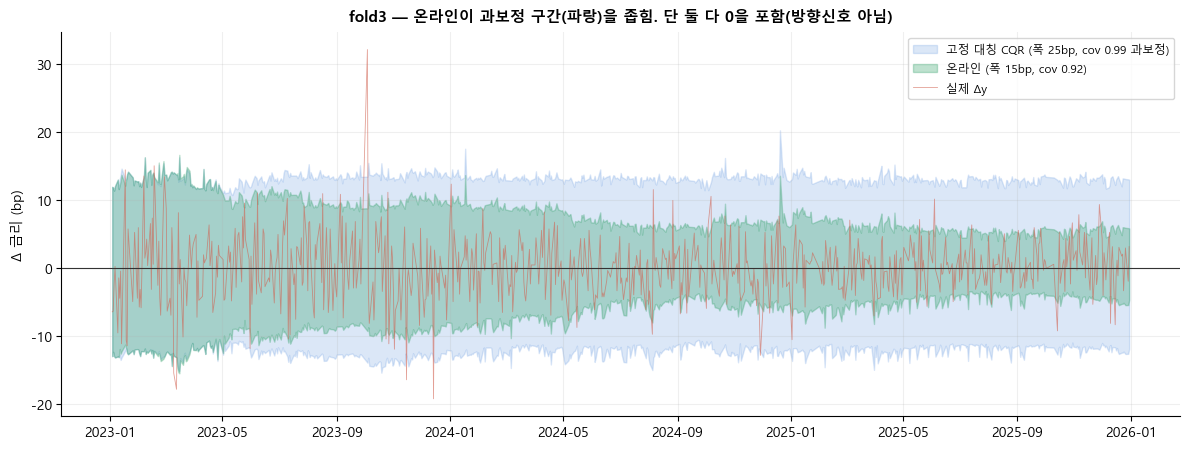

고정 대칭 CQR  0배제율=0.024
온라인 롤링     0배제율=0.003


In [5]:
f3=iv[iv['fold']=='fold3'].reset_index(drop=True)
fig,ax=plt.subplots(figsize=(12,4.6))
ax.fill_between(f3['date'], f3['sym_lo'], f3['sym_hi'], color=C['sym'], alpha=0.18, label=f'고정 대칭 CQR (폭 25bp, cov 0.99 과보정)')
ax.fill_between(f3['date'], f3['online_lo'], f3['online_hi'], color=C['online'], alpha=0.30, label=f'온라인 (폭 15bp, cov 0.92)')
ax.plot(f3['date'], f3['y_true'], color='#d1604f', lw=0.6, alpha=0.6, label='실제 Δy')
ax.axhline(0, color='#333', lw=0.8)
ax.set_ylabel('Δ 금리 (bp)'); ax.set_title('fold3 — 온라인이 과보정 구간(파랑)을 좁힘. 단 둘 다 0을 포함(방향신호 아님)', fontweight='bold', fontsize=11, pad=8)
ax.legend(fontsize=8.5, loc='upper right'); ax.spines[['top','right']].set_visible(False); ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig(FIG/'12_online_vs_static_fold3.png', dpi=150, bbox_inches='tight'); plt.show()
for m in ['sym','online']:
    print(f'{NM[m]:10s} 0배제율={excl0(iv[f"{m}_lo"],iv[f"{m}_hi"]):.3f}')

---
## 5. 결론

- **비교차 정렬**로 분위수 교차 제거(문제 a).
- **고정 CQR은 실패**: fold3 과보정(99%/25bp)·fold2 미달(67%) — cal≠test 레짐이면 깨짐(문제 b). pooled가 이를 은폐.
- **온라인 롤링 conformal이 해결**: 마진 0.905·세 fold 0.88~0.92·폭 14.8bp·Interval Score 20.0(최저)·레짐 균형(고변동 0.89/저변동 0.92).
- **방향은 구간이 아니라 q50 부호**: 제대로 보정하면 0배제율≈0 (문제 c의 정직한 결말). 구간의 역할은 불확실성 표현.

### 정직한 한계
- 온라인도 *정확한* 조건부 커버리지를 보장하진 않음 — "근사 개선".
- 예측구간으로 방향 베팅을 만들려던 초기 가설은 **기각**: 방향 가치는 점예측(q50)에 있고, 구간은 불확실성 크기를 보일 뿐. (정직성 = 강점)

### 다음
- [ ] 13 백테스트 + 2026 라이브 OOS (§3.2)